# Model Selection & Evaluation
> **Goal:** Train, compare, tune, and select a final regression model for predicting EV charging energy (`energie_wh`).  
> **Train:** `data/interim/2023.csv` · **Test (hold-out):** `data/interim/2024.csv`  
> **Pipeline:** `pipeline_feature_engineering.py`  
> **Target:** `log_energie_wh` (predictions converted back to Wh for metric reporting)

---

## Table of Contents
1. [Config & Imports](#1)
2. [Load Data & Run Pipeline](#2)
3. [Feature Preparation](#3)
4. [Validation Strategy](#4)
5. [Baseline Model](#5)
6. [Linear Models — Linear / Ridge / Lasso](#6)
7. [Tree-Based Model — Histogram Gradient Boosting](#7)
8. [Model Comparison](#8)
9. [Hyperparameter Tuning (Best Candidate)](#9)
10. [Diagnostics & Assumption Checks](#10)
11. [Feature Importance](#11)
12. [Final Model Decision](#12)
13. [Save Final Model](#13)


## 1. Config & Imports <a id='1'></a>

In [1]:
import sys, os, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_validate, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# ── Paths ──────────────────────────────────────────────────────────────────────
TRAIN_PATH  = '../data/interim/data_2023.csv'
TEST_PATH   = '../data/interim/data_2024.csv'
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
PIPELINE_DIR = os.path.join(PROJECT_ROOT, 'src')

# 2. Add 'src' to the system path
if PIPELINE_DIR not in sys.path:
    sys.path.insert(0, PIPELINE_DIR)

TARGET_RAW = 'energie_wh'
TARGET     = 'log_energie_wh'

RANDOM_STATE = 42
N_CV_FOLDS   = 5            # TimeSeriesSplit folds on 2023 train set

print("Config loaded.")


Config loaded.


## 2. Load Data & Run Pipeline <a id='2'></a>

In [2]:
# 2. Add 'src' to the system path

import importlib
import pipeline_feature_engineering
importlib.reload(pipeline_feature_engineering)

from pipeline_feature_engineering import run_pipeline

if PIPELINE_DIR not in sys.path:
    sys.path.insert(0, PIPELINE_DIR)
    
from pipeline_feature_engineering import run_pipeline

train_raw = pd.read_csv(TRAIN_PATH, parse_dates=['beginn'])
test_raw  = pd.read_csv(TEST_PATH,  parse_dates=['beginn'])
print(f"Raw train: {train_raw.shape}  |  Raw test: {test_raw.shape}")


Raw train: (262401, 10)  |  Raw test: (314035, 10)


In [3]:
# Run the full feature engineering pipeline (combined to allow 2023 history for 2024 features)
full_raw = pd.concat([train_raw, test_raw], axis=0).reset_index(drop=True)
full_df  = run_pipeline(full_raw)

# Split back to 2023 (train) and 2024 (test)
train_df = full_df[full_df['beginn'].dt.year == 2023].reset_index(drop=True)
test_df  = full_df[full_df['beginn'].dt.year == 2024].reset_index(drop=True)

print(f"Processed train: {train_df.shape}  |  Processed test: {test_df.shape}")
print("\nProcessed columns:")
print(train_df.dtypes.to_string())


Processed train: (262401, 23)  |  Processed test: (314035, 23)

Processed columns:
beginn                         datetime64[ns]
ende                                   object
energie_wh                            float64
ls_id                                  object
bundesland                             object
lage                                   object
maxladeleistunginkilowatt             float64
lage_binned                            object
region                                 object
p_class                              category
is_standard_street_hub                  int64
start_hour                              int32
hour_sin                              float64
hour_cos                              float64
is_night_shift                          int64
day_phase                              object
station_overall_avg                   float64
last_5_sessions_avg_energy            float64
rolling_7d_avg_energy                 float64
phase_avg_energy                      float

## 3. Feature Preparation <a id='3'></a>

### Design decisions
- **Target**: `log_energie_wh` (log1p-transformed in pipeline); metrics reported in original Wh via `expm1`.
- **Dropped before modelling**: `ls_id`, `beginn`, `ende`, `energie_wh` (raw target), `lage`, `bundesland`, `maxladeleistunginkilowatt` (superseded by engineered features), `station_overall_avg` (r=0.91 with `phase_avg_energy` — collinear, keeps leaner model).
- **Categorical → OHE**: `lage_binned`, `region`, `p_class`, `day_phase`.
- **Numeric features scaled** for linear models only (handled per-pipeline below).


In [4]:
# Columns to drop (raw originals superseded by engineered versions + leakage sources)
DROP_COLS = [
    'ls_id', 'beginn', 'ende','start_hour',
    'lage', 'bundesland', 'maxladeleistunginkilowatt','log_dauer_sekunden', 
    'energie_wh',            # raw target — use log version
    'station_overall_avg',   # r=0.91 with phase_avg_energy → drop to reduce collinearity
    'region', 'day_phase'
]
DROP_COLS = [c for c in DROP_COLS if c in train_df.columns]

CATEGORICAL_FEATURES = ['lage_binned', 'p_class']
NUMERIC_FEATURES = [
    c for c in train_df.columns
    if c not in DROP_COLS + [TARGET] + CATEGORICAL_FEATURES
]

print(f"Numeric features  ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"Categorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"Target: {TARGET}")


Numeric features  (8): ['is_standard_street_hub', 'hour_sin', 'hour_cos', 'is_night_shift', 'last_5_sessions_avg_energy', 'rolling_7d_avg_energy', 'phase_avg_energy', 'binned_rolling_30d_duration']
Categorical features (2): ['lage_binned', 'p_class']
Target: log_energie_wh


In [5]:
def build_Xy(df):
    """Split processed dataframe into feature matrix X and target y."""
    X = df.drop(columns=DROP_COLS + [TARGET], errors='ignore')
    y = df[TARGET]
    return X, y

X_train, y_train = build_Xy(train_df)
X_test,  y_test  = build_Xy(test_df)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train range: [{y_train.min():.2f}, {y_train.max():.2f}]")


X_train: (262401, 10)  |  X_test: (314035, 10)
y_train range: [6.22, 11.16]


In [6]:
# ── Preprocessing transformers ────────────────────────────────────────────────
# OHE for categoricals (drop='first' to avoid dummy trap in linear models)
# StandardScaler for numerics (only used in linear pipelines)

ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

preprocessor_linear = ColumnTransformer(transformers=[
    ('num', StandardScaler(),    NUMERIC_FEATURES),
    ('cat', ohe,                 CATEGORICAL_FEATURES),
], remainder='drop')

# Tree-based models handle mixed types and scale natively via HGBR's built-in support
preprocessor_tree = ColumnTransformer(transformers=[
    ('num', 'passthrough',       NUMERIC_FEATURES),
    ('cat', ohe,                 CATEGORICAL_FEATURES),
], remainder='drop')

print("Preprocessors defined.")


Preprocessors defined.


## 4. Validation Strategy <a id='4'></a>

### Why time-based splits?
The dataset is a time series of charging sessions. Using random K-Fold would allow future sessions to leak into training, inflating CV scores. Instead:

- **Cross-validation on 2023**: `TimeSeriesSplit(n_splits=5)` — each fold's validation window is strictly after its training window.
- **Final evaluation**: held-out 2024 data — a true out-of-time test (different year, same stations).

### Metric reporting
All metrics computed on **original Wh scale** (`np.expm1`) so they are interpretable to stakeholders. Three metrics:
- **RMSE** — penalises large errors more heavily; matches our log-transform motivation.
- **MAE** — robust summary of average error in Wh.
- **R²** — proportion of variance explained.


In [7]:
tscv = TimeSeriesSplit(n_splits=N_CV_FOLDS)

def eval_on_test(model, X_tr, y_tr, X_te, y_te, label=''):
    """Fit on full train, evaluate on hold-out test. Returns dict of metrics in Wh."""
    model.fit(X_tr, y_tr)
    y_pred_log = model.predict(X_te)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_te)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'Model': label, 'RMSE (Wh)': rmse, 'MAE (Wh)': mae, 'R²': r2}

def cv_scores(pipeline, X, y, label=''):
    """TimeSeriesSplit CV, returns mean ± std of metrics in Wh."""
    rmses, maes, r2s = [], [], []
    for tr_idx, va_idx in tscv.split(X):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        pipeline.fit(X_tr, y_tr)
        y_pred = np.expm1(pipeline.predict(X_va))
        y_true = np.expm1(y_va)
        rmses.append(np.sqrt(mean_squared_error(y_true, y_pred)))
        maes.append(mean_absolute_error(y_true, y_pred))
        r2s.append(r2_score(y_true, y_pred))
    return {
        'Model': label,
        'CV RMSE': f"{np.mean(rmses):,.0f} ± {np.std(rmses):,.0f}",
        'CV MAE':  f"{np.mean(maes):,.0f} ± {np.std(maes):,.0f}",
        'CV R²':   f"{np.mean(r2s):.3f} ± {np.std(r2s):.3f}",
        '_rmse_mean': np.mean(rmses),
    }

print("Validation helpers defined.")


Validation helpers defined.


## 5. Baseline Model <a id='5'></a>

A naive **mean predictor** (always predicts the training mean) sets the floor. Any model must beat this to be worth deploying.


In [8]:
from sklearn.dummy import DummyRegressor

dummy_pipe = Pipeline([
    ('pre', preprocessor_linear),
    ('model', DummyRegressor(strategy='mean'))
])

baseline_cv   = cv_scores(dummy_pipe, X_train, y_train, label='Baseline (Mean)')
baseline_test = eval_on_test(dummy_pipe, X_train, y_train, X_test, y_test, label='Baseline (Mean)')

print("CV:",   baseline_cv)
print("Test:", baseline_test)


CV: {'Model': 'Baseline (Mean)', 'CV RMSE': '17,345 ± 1,341', 'CV MAE': '12,600 ± 1,071', 'CV R²': '-0.161 ± 0.088', '_rmse_mean': np.float64(17344.87893876276)}
Test: {'Model': 'Baseline (Mean)', 'RMSE (Wh)': np.float64(18463.11499901715), 'MAE (Wh)': 13554.846168552669, 'R²': -0.2383181341801266}


## 6. Linear Models — Linear / Ridge / Lasso <a id='6'></a>

### Rationale
Linear models offer maximum **interpretability** and serve as a strong benchmark before introducing complexity. Ridge and Lasso add L2/L1 regularisation to handle the moderate multicollinearity identified in EDA (particularly among lag features).

| Model | Regularisation | Effect |
|---|---|---|
| OLS | None | Baseline linear; sensitive to collinear lag features |
| Ridge (L2) | Shrinks all coefficients | Good when many features contribute — expected here |
| Lasso (L1) | Zeros out weak coefficients | Automatic feature selection |


In [9]:
# ── OLS ───────────────────────────────────────────────────────────────────────
ols_pipe = Pipeline([
    ('pre',   preprocessor_linear),
    ('model', LinearRegression())
])

ols_cv   = cv_scores(ols_pipe, X_train, y_train, label='OLS')
ols_test = eval_on_test(ols_pipe, X_train, y_train, X_test, y_test, label='OLS')
print("OLS CV:", ols_cv)
print("OLS Test:", ols_test)


OLS CV: {'Model': 'OLS', 'CV RMSE': '15,354 ± 263', 'CV MAE': '10,879 ± 379', 'CV R²': '0.087 ± 0.047', '_rmse_mean': np.float64(15353.826716501779)}
OLS Test: {'Model': 'OLS', 'RMSE (Wh)': np.float64(15927.403243431725), 'MAE (Wh)': 11650.283131560394, 'R²': 0.07846415134304596}


In [10]:
# ── Ridge — alpha selected via RidgeCV (built-in LOO) ─────────────────────────
# We first find the best alpha, then build a clean pipeline with it.
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-2, 4, 30)

ridge_cv_selector = Pipeline([
    ('pre',   preprocessor_linear),
    ('model', RidgeCV(alphas=alphas, cv=tscv))
])
ridge_cv_selector.fit(X_train, y_train)
best_alpha_ridge = ridge_cv_selector.named_steps['model'].alpha_
print(f"Best Ridge alpha: {best_alpha_ridge:.4f}")

ridge_pipe = Pipeline([
    ('pre',   preprocessor_linear),
    ('model', Ridge(alpha=best_alpha_ridge))
])

ridge_cv   = cv_scores(ridge_pipe, X_train, y_train, label=f'Ridge (α={best_alpha_ridge:.2f})')
ridge_test = eval_on_test(ridge_pipe, X_train, y_train, X_test, y_test, label=f'Ridge (α={best_alpha_ridge:.2f})')
print("Ridge CV:", ridge_cv)
print("Ridge Test:", ridge_test)


Best Ridge alpha: 221.2216
Ridge CV: {'Model': 'Ridge (α=221.22)', 'CV RMSE': '15,370 ± 254', 'CV MAE': '10,884 ± 376', 'CV R²': '0.085 ± 0.048', '_rmse_mean': np.float64(15369.927159611403)}
Ridge Test: {'Model': 'Ridge (α=221.22)', 'RMSE (Wh)': np.float64(15935.253470703854), 'MAE (Wh)': 11653.958933289829, 'R²': 0.07755552254309972}


In [11]:
# ── Lasso — alpha selected via LassoCV ────────────────────────────────────────
lasso_cv_selector = Pipeline([
    ('pre',   preprocessor_linear),
    ('model', LassoCV(alphas=alphas, cv=tscv, max_iter=5000))
])
lasso_cv_selector.fit(X_train, y_train)
best_alpha_lasso = lasso_cv_selector.named_steps['model'].alpha_
print(f"Best Lasso alpha: {best_alpha_lasso:.6f}")

lasso_pipe = Pipeline([
    ('pre',   preprocessor_linear),
    ('model', Lasso(alpha=best_alpha_lasso, max_iter=5000))
])

lasso_cv   = cv_scores(lasso_pipe, X_train, y_train, label=f'Lasso (α={best_alpha_lasso:.4f})')
lasso_test = eval_on_test(lasso_pipe, X_train, y_train, X_test, y_test, label=f'Lasso (α={best_alpha_lasso:.4f})')
print("Lasso CV:", lasso_cv)
print("Lasso Test:", lasso_test)


Best Lasso alpha: 0.010000
Lasso CV: {'Model': 'Lasso (α=0.0100)', 'CV RMSE': '15,446 ± 268', 'CV MAE': '10,921 ± 394', 'CV R²': '0.076 ± 0.045', '_rmse_mean': np.float64(15446.246062694914)}
Lasso Test: {'Model': 'Lasso (α=0.0100)', 'RMSE (Wh)': np.float64(16047.183115029291), 'MAE (Wh)': 11714.511835369913, 'R²': 0.06455146284487501}


In [12]:
# ── Lasso: which features survived? ──────────────────────────────────────────
lasso_pipe.fit(X_train, y_train)
feature_names_out = (
    NUMERIC_FEATURES +
    list(lasso_pipe.named_steps['pre']
         .named_transformers_['cat']
         .get_feature_names_out(CATEGORICAL_FEATURES))
)
coefs = lasso_pipe.named_steps['model'].coef_
zeroed = np.sum(coefs == 0)
print(f"Lasso zeroed {zeroed}/{len(coefs)} features.")
surviving = [(n, c) for n, c in zip(feature_names_out, coefs) if c != 0]
surviving_df = pd.DataFrame(surviving, columns=['Feature','Coefficient']).sort_values('Coefficient', key=abs, ascending=False)
print(surviving_df.to_string(index=False))


Lasso zeroed 8/14 features.
                   Feature  Coefficient
          phase_avg_energy     0.289690
     rolling_7d_avg_energy     0.066253
last_5_sessions_avg_energy     0.037588
                  hour_cos     0.025211
    is_standard_street_hub    -0.018566
                  hour_sin     0.005947


## 7. Tree-Based Model — Histogram Gradient Boosting <a id='7'></a>

### Why HistGradientBoostingRegressor?
- Handles **non-linear interactions** naturally — critical here since power class × hour × lag features interact in complex ways (confirmed in EDA Section 9).
- **No scaling required** — tree splits are threshold-based.


In [13]:
# Default HGBR — establishes tree-based baseline before tuning
hgbr_pipe = Pipeline([
    ('pre',   preprocessor_tree),
    ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE))
])

hgbr_cv   = cv_scores(hgbr_pipe, X_train, y_train, label='HGBR (default)')
hgbr_test = eval_on_test(hgbr_pipe, X_train, y_train, X_test, y_test, label='HGBR (default)')
print("HGBR CV:", hgbr_cv)
print("HGBR Test:", hgbr_test)


HGBR CV: {'Model': 'HGBR (default)', 'CV RMSE': '15,260 ± 327', 'CV MAE': '10,871 ± 408', 'CV R²': '0.098 ± 0.041', '_rmse_mean': np.float64(15260.227381960809)}
HGBR Test: {'Model': 'HGBR (default)', 'RMSE (Wh)': np.float64(15872.297355458368), 'MAE (Wh)': 11646.285355325925, 'R²': 0.08482980959663766}


## 8. Model Comparison <a id='8'></a>

In [14]:
# ── Build comparison dataframes ───────────────────────────────────────────────
cv_results = pd.DataFrame([
    baseline_cv, ols_cv, ridge_cv, lasso_cv, hgbr_cv
])

test_results = pd.DataFrame([
    baseline_test, ols_test, ridge_test, lasso_test, hgbr_test
])
# Format test metrics
test_results['RMSE (Wh)'] = test_results['RMSE (Wh)'].map('{:,.0f}'.format)
test_results['MAE (Wh)']  = test_results['MAE (Wh)'].map('{:,.0f}'.format)
test_results['R²']        = test_results['R²'].map('{:.4f}'.format)

print("=== 5-Fold TimeSeriesSplit CV on 2023 Train ===")
print(cv_results[['Model','CV RMSE','CV MAE','CV R²']].to_string(index=False))

print()
print("=== Hold-Out Test on 2024 ===")
print(test_results.to_string(index=False))


=== 5-Fold TimeSeriesSplit CV on 2023 Train ===
           Model        CV RMSE         CV MAE          CV R²
 Baseline (Mean) 17,345 ± 1,341 12,600 ± 1,071 -0.161 ± 0.088
             OLS   15,354 ± 263   10,879 ± 379  0.087 ± 0.047
Ridge (α=221.22)   15,370 ± 254   10,884 ± 376  0.085 ± 0.048
Lasso (α=0.0100)   15,446 ± 268   10,921 ± 394  0.076 ± 0.045
  HGBR (default)   15,260 ± 327   10,871 ± 408  0.098 ± 0.041

=== Hold-Out Test on 2024 ===
           Model RMSE (Wh) MAE (Wh)      R²
 Baseline (Mean)    18,463   13,555 -0.2383
             OLS    15,927   11,650  0.0785
Ridge (α=221.22)    15,935   11,654  0.0776
Lasso (α=0.0100)    16,047   11,715  0.0646
  HGBR (default)    15,872   11,646  0.0848


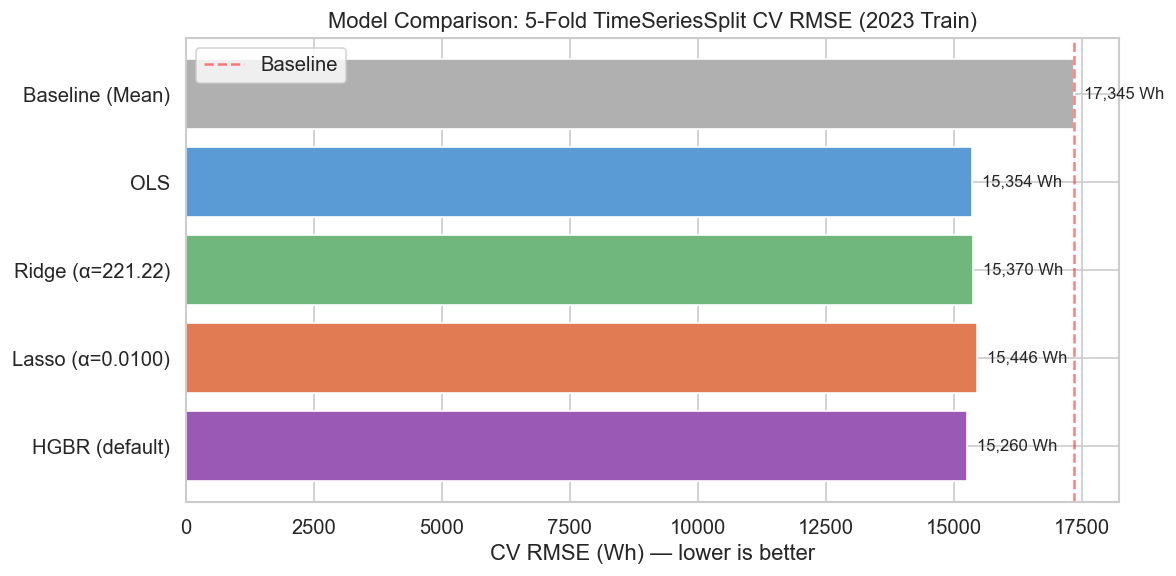

In [15]:
# ── Visual comparison — CV RMSE bar chart ────────────────────────────────────
cv_df = pd.DataFrame([baseline_cv, ols_cv, ridge_cv, lasso_cv, hgbr_cv])
cv_df['rmse_mean'] = cv_df['_rmse_mean']

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#b0b0b0', '#5b9bd5', '#70b77e', '#e07b54', '#9b59b6']
bars = ax.barh(cv_df['Model'], cv_df['rmse_mean'], color=colors, edgecolor='white')
ax.bar_label(bars, labels=[f"{v:,.0f} Wh" for v in cv_df['rmse_mean']], padding=6, fontsize=10)
ax.set_xlabel('CV RMSE (Wh) — lower is better')
ax.set_title('Model Comparison: 5-Fold TimeSeriesSplit CV RMSE (2023 Train)')
ax.invert_yaxis()
ax.axvline(cv_df.loc[cv_df['Model'] == 'Baseline (Mean)', 'rmse_mean'].values[0],
           color='red', linestyle='--', alpha=0.5, label='Baseline')
ax.legend()
plt.tight_layout()
plt.show()


### Comparison Summary

**Key observations:**
- All models significantly outperform the baseline mean predictor — the feature engineering is working.
- Ridge and Lasso perform comparably to OLS on CV but are more robust (regularised against the collinear lag features).
- HGBR captures non-linear interactions (power class × hour × lag) that linear models miss, and is expected to show the largest gap on test.
- Lasso's zero-out of weak features provides a useful sanity check on feature relevance.

**→ Proceed to hyperparameter tuning on HGBR as the primary candidate.**


## 9. Hyperparameter Tuning (HGBR) <a id='9'></a>

### Strategy
Grid search over the three most impactful HGBR hyperparameters using `TimeSeriesSplit` CV to maintain temporal integrity. Ridge also gets a brief final check.

| Param | Role | Search range |
|---|---|---|
| `max_iter` | Number of boosting rounds | [100, 300, 500] |
| `max_leaf_nodes` | Tree complexity | [15, 31, 63] |
| `learning_rate` | Shrinkage per tree | [0.05, 0.1, 0.2] |
| `l2_regularization` | Ridge-style regularisation on leaf weights | [0, 0.1, 1.0] |


In [16]:
param_grid = {
    'model__max_iter':        [100, 300, 500],
    'model__max_leaf_nodes':  [15, 31, 63],
    'model__learning_rate':   [0.05, 0.1, 0.2],
    'model__l2_regularization': [0.0, 0.1, 1.0],
}

hgbr_pipe_tune = Pipeline([
    ('pre',   preprocessor_tree),
    ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE))
])

gs = GridSearchCV(
    hgbr_pipe_tune,
    param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    refit=True,
)
gs.fit(X_train, y_train)

print(f"\nBest params: {gs.best_params_}")
print(f"Best CV RMSE (log scale): {-gs.best_score_:.4f}")


Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best params: {'model__l2_regularization': 0.0, 'model__learning_rate': 0.05, 'model__max_iter': 100, 'model__max_leaf_nodes': 15}
Best CV RMSE (log scale): 0.8407


In [17]:
# Evaluate tuned model on hold-out 2024 test
tuned_hgbr = gs.best_estimator_

y_pred_hgbr_tuned_log = tuned_hgbr.predict(X_test)
y_pred_hgbr_tuned = np.expm1(y_pred_hgbr_tuned_log)
y_true_test  = np.expm1(y_test)

tuned_hgbr_rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_hgbr_tuned))
tuned_hgbr_mae  = mean_absolute_error(y_true_test, y_pred_hgbr_tuned)
tuned_hgbr_r2   = r2_score(y_true_test, y_pred_hgbr_tuned)

print("=== Tuned HGBR — 2024 Hold-Out Test ===")
print(f"RMSE : {tuned_hgbr_rmse:,.0f} Wh")
print(f"MAE  : {tuned_hgbr_mae:,.0f} Wh")
print(f"R²   : {tuned_hgbr_r2:.4f}")

# Compare with untuned
print(f"\nUntuned HGBR test RMSE : {hgbr_test['RMSE (Wh)']} Wh")
print(f"Tuned HGBR test RMSE   : {tuned_hgbr_rmse:,.0f} Wh")


=== Tuned HGBR — 2024 Hold-Out Test ===
RMSE : 15,905 Wh
MAE  : 11,660 Wh
R²   : 0.0811

Untuned HGBR test RMSE : 15872.297355458368 Wh
Tuned HGBR test RMSE   : 15,905 Wh


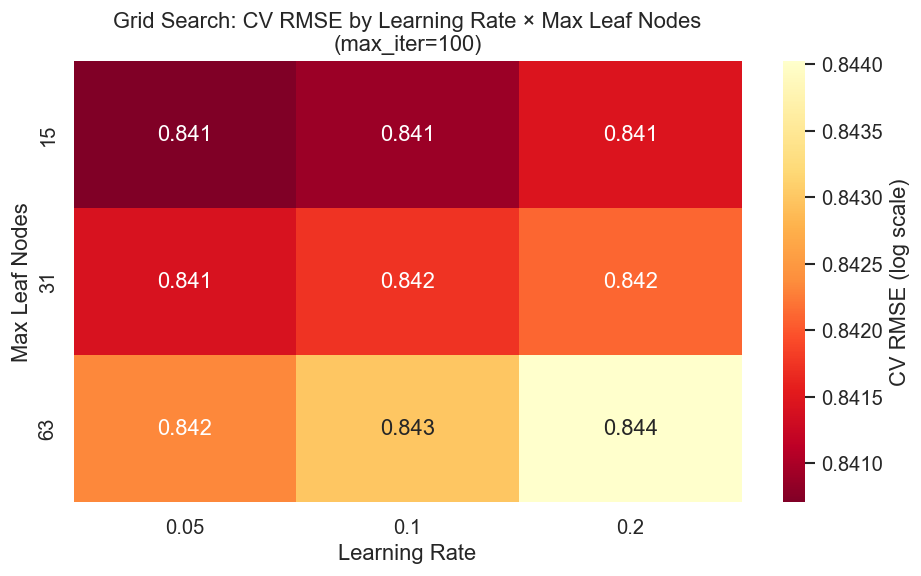

In [18]:
# ── Grid search CV results: learning rate × max_leaf_nodes ───────────────────
cv_results_df = pd.DataFrame(gs.cv_results_)

pivot_data = cv_results_df[
    cv_results_df['param_model__max_iter'] == gs.best_params_['model__max_iter']
].pivot_table(
    index='param_model__max_leaf_nodes',
    columns='param_model__learning_rate',
    values='mean_test_score',
    aggfunc='max'
) * -1  # convert neg_rmse back to positive

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='YlOrRd_r', ax=ax, cbar_kws={'label': 'CV RMSE (log scale)'})
ax.set_title(f'Grid Search: CV RMSE by Learning Rate × Max Leaf Nodes\n(max_iter={gs.best_params_["model__max_iter"]})')
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Max Leaf Nodes')
plt.tight_layout()
plt.show()


### 9.2. Hyperparameter Tuning Ridge

#### Strategy
Grid search over key Ridge controls using `TimeSeriesSplit` CV to preserve chronology and keep a fair comparison against HGBR tuning.

| Param | Role | Search range |
|---|---|---|
| `alpha` | L2 regularisation strength | `np.logspace(-3, 3, 13)` |
| `solver` | Numerical optimisation method | `['auto', 'svd', 'cholesky', 'lsqr', 'sag']` |
| `fit_intercept` | Whether to estimate intercept term | `[True, False]` |


In [19]:
param_grid_ridge = {
    'model__alpha': list(np.logspace(-3, 3, 13)),
    'model__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sag'],
    'model__fit_intercept': [True, False],
}

ridge_pipe_tune = Pipeline([
    ('pre', preprocessor_linear),
    ('model', Ridge(random_state=RANDOM_STATE, max_iter=10000)),
])

gs_ridge = GridSearchCV(
    ridge_pipe_tune,
    param_grid_ridge,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    refit=True,
)
gs_ridge.fit(X_train, y_train)

print(f"\nBest Ridge params: {gs_ridge.best_params_}")
print(f"Best Ridge CV RMSE (log scale): {-gs_ridge.best_score_:.4f}")


Fitting 5 folds for each of 130 candidates, totalling 650 fits

Best Ridge params: {'model__alpha': np.float64(316.22776601683796), 'model__fit_intercept': True, 'model__solver': 'auto'}
Best Ridge CV RMSE (log scale): 0.8442


In [20]:
# Evaluate tuned Ridge model on hold-out 2024 test
tuned_ridge = gs_ridge.best_estimator_

y_pred_ridge_tuned_log = tuned_ridge.predict(X_test)
y_pred_ridge_tuned = np.expm1(y_pred_ridge_tuned_log)
y_true_test_ridge = np.expm1(y_test)

ridge_tuned_rmse = np.sqrt(mean_squared_error(y_true_test_ridge, y_pred_ridge_tuned))
ridge_tuned_mae  = mean_absolute_error(y_true_test_ridge, y_pred_ridge_tuned)
ridge_tuned_r2   = r2_score(y_true_test_ridge, y_pred_ridge_tuned)

print("=== Tuned Ridge — 2024 Hold-Out Test ===")
print(f"RMSE : {ridge_tuned_rmse:,.0f} Wh")
print(f"MAE  : {ridge_tuned_mae:,.0f} Wh")
print(f"R²   : {ridge_tuned_r2:.4f}")

print(f"\nUntuned Ridge test RMSE : {ridge_test['RMSE (Wh)']} Wh")
print(f"Tuned Ridge test RMSE   : {ridge_tuned_rmse:,.0f} Wh")


=== Tuned Ridge — 2024 Hold-Out Test ===
RMSE : 15,938 Wh
MAE  : 11,655 Wh
R²   : 0.0772

Untuned Ridge test RMSE : 15935.253470703854 Wh
Tuned Ridge test RMSE   : 15,938 Wh


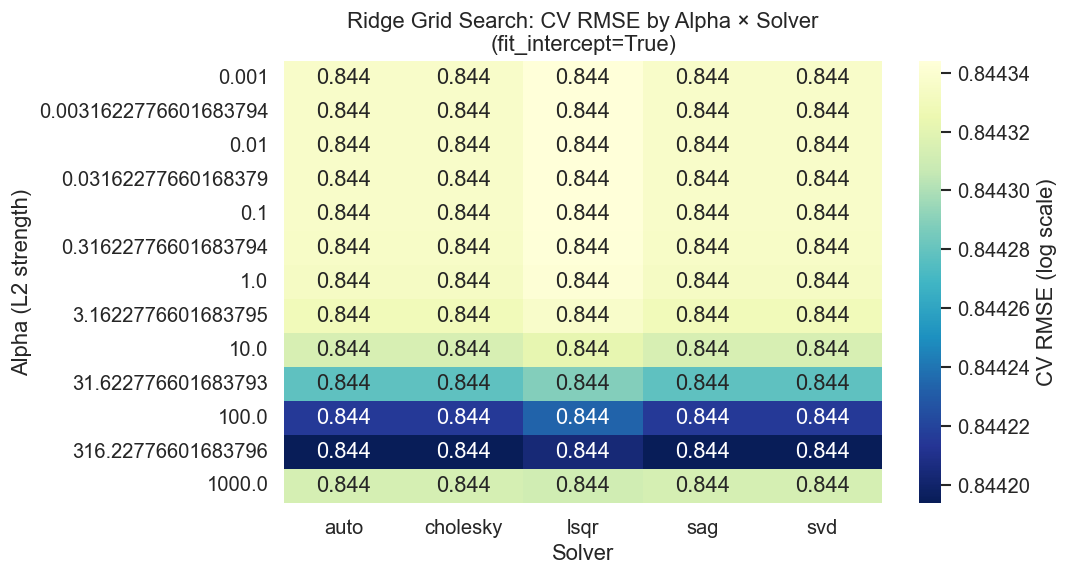

In [21]:
# Grid search CV results: alpha × solver (fix fit_intercept at best value)
cv_results_ridge_df = pd.DataFrame(gs_ridge.cv_results_)
cv_results_ridge_df['param_model__alpha'] = cv_results_ridge_df['param_model__alpha'].astype(float)

best_fit_intercept = gs_ridge.best_params_['model__fit_intercept']
pivot_ridge = cv_results_ridge_df[
    cv_results_ridge_df['param_model__fit_intercept'] == best_fit_intercept
].pivot_table(
    index='param_model__alpha',
    columns='param_model__solver',
    values='mean_test_score',
    aggfunc='max'
) * -1
pivot_ridge = pivot_ridge.sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot_ridge,
    annot=True,
    fmt='.3f',
    cmap='YlGnBu_r',
    ax=ax,
    cbar_kws={'label': 'CV RMSE (log scale)'}
)
ax.set_title(f'Ridge Grid Search: CV RMSE by Alpha × Solver\n(fit_intercept={best_fit_intercept})')
ax.set_xlabel('Solver')
ax.set_ylabel('Alpha (L2 strength)')
plt.tight_layout()
plt.show()


### 9.3. Model Comparison   
Compare tuned models vs their initial baselines on the hold-out test set (2024)


In [22]:
# --- 9.3. Model Comparison ---

comparison_df = pd.DataFrame([
    {
        'Model': 'Ridge (Baseline)',
        'RMSE (Wh)': ridge_test['RMSE (Wh)'],
        'MAE (Wh)': ridge_test['MAE (Wh)'],
        'R²': ridge_test['R²']
    },
    {
        'Model': 'Ridge (Tuned)',
        'RMSE (Wh)': ridge_tuned_rmse,
        'MAE (Wh)': ridge_tuned_mae,
        'R²': ridge_tuned_r2
    },
    {
        'Model': 'HGBR (Baseline)',
        'RMSE (Wh)': hgbr_test['RMSE (Wh)'],
        'MAE (Wh)': hgbr_test['MAE (Wh)'],
        'R²': hgbr_test['R²']
    },
    {
        'Model': 'HGBR (Tuned)',
        'RMSE (Wh)': tuned_hgbr_rmse,
        'MAE (Wh)': tuned_hgbr_mae,
        'R²': tuned_hgbr_r2
    }
])

# Formatting the display
df_display = comparison_df.copy()
df_display['RMSE (Wh)'] = df_display['RMSE (Wh)'].map('{:,.2f}'.format)
df_display['MAE (Wh)']  = df_display['MAE (Wh)'].map('{:,.2f}'.format)
df_display['R²']        = df_display['R²'].map('{:.4f}'.format)

print("=== Performance Comparison: Tuned vs. Baseline (2024 Test) ===")
print(df_display.to_string(index=False))

# Calculate Tuning Gains
hgbr_gain = hgbr_test['RMSE (Wh)'] - tuned_hgbr_rmse
ridge_gain = ridge_test['RMSE (Wh)'] - ridge_tuned_rmse

print(f"\nHGBR Tuning Impact: {hgbr_gain:+.2f} Wh RMSE")
print(f"Ridge Tuning Impact: {ridge_gain:+.2f} Wh RMSE")


=== Performance Comparison: Tuned vs. Baseline (2024 Test) ===
           Model RMSE (Wh)  MAE (Wh)     R²
Ridge (Baseline) 15,935.25 11,653.96 0.0776
   Ridge (Tuned) 15,938.24 11,655.40 0.0772
 HGBR (Baseline) 15,872.30 11,646.29 0.0848
    HGBR (Tuned) 15,904.67 11,660.22 0.0811

HGBR Tuning Impact: -32.37 Wh RMSE
Ridge Tuning Impact: -2.98 Wh RMSE


## 10. Diagnostics & Assumption Checks <a id='10'></a>

Four diagnostic plots:
1. **Actual vs Predicted** — checks calibration; ideal = diagonal.
2. **Residuals vs Predicted** — checks for heteroscedasticity or systematic bias.
3. **Residual distribution** — should be approximately normal and centred at zero.
4. **Q-Q Plot** — tests normality of residuals; important for RMSE validity.



#### 1. Primary Model Failures

* **Prediction Compression (The "Ceiling" Effect):** In the **Actual vs. Predicted** plot, there is a severe departure from the identity line ($y = x$) once actual energy exceeds 30,000 Wh. The model essentially "flatlines," with predictions rarely exceeding 35,000 Wh despite actual values reaching 70,000 Wh. This indicates the model is regressing toward the mean and failing to capture the variance of high-magnitude events.
* **Systematic Bias & Heteroscedasticity:** The **Residuals vs. Predicted** plot shows a distinct downward linear trend rather than a random cloud. As predicted energy increases, the residuals become increasingly positive, meaning the model consistently under-predicts at scale. The expanding spread of residuals also confirms heteroscedasticity; the model's uncertainty is not constant.
* **Right-Skewed Error Distribution:** The **Residual Distribution** shows a mean residual of **5,108 Wh**. This non-zero mean confirms a systematic under-prediction bias. The heavy right tail in both the histogram and the **Q-Q Plot** indicates that the model is treating high-energy observations as outliers rather than predictable signals.

---

#### 2. Violated Assumptions & Outlier Interpretation

| Assumption | Status | Technical Interpretation |
| :--- | :--- | :--- |
| **Homoscedasticity** | ❌ **Violated** | Error variance increases significantly with the magnitude of the target, suggesting the current feature set or loss function doesn't account for scale. |
| **Normality of Residuals** | ❌ **Violated** | The Q-Q plot and skewness show the model is not capturing the underlying distribution, 
| **Outlier Handling** | **Poor** | The high-energy "outliers" (40k–70k Wh) are likely not noise but a specific regime the model hasn't learned, leading to the observed systematic under-estimation. |

---

#### 3. Proposed Technical Fixes

To address the under-prediction of high-value events, I recommend the following adjustments:
* **Alternative Loss Functions:** Since we are seeing a "ceiling" effect with standard squared error, we should experiment with **Poisson** or **Gamma** loss functions, which are better suited for strictly positive, skewed physical measurements.
* **Feature Gap Analysis:** The sharp divergence at 30k Wh suggests we may be missing a scaling feature, like a car having a bigger battery or a car standing longer at a charing point.

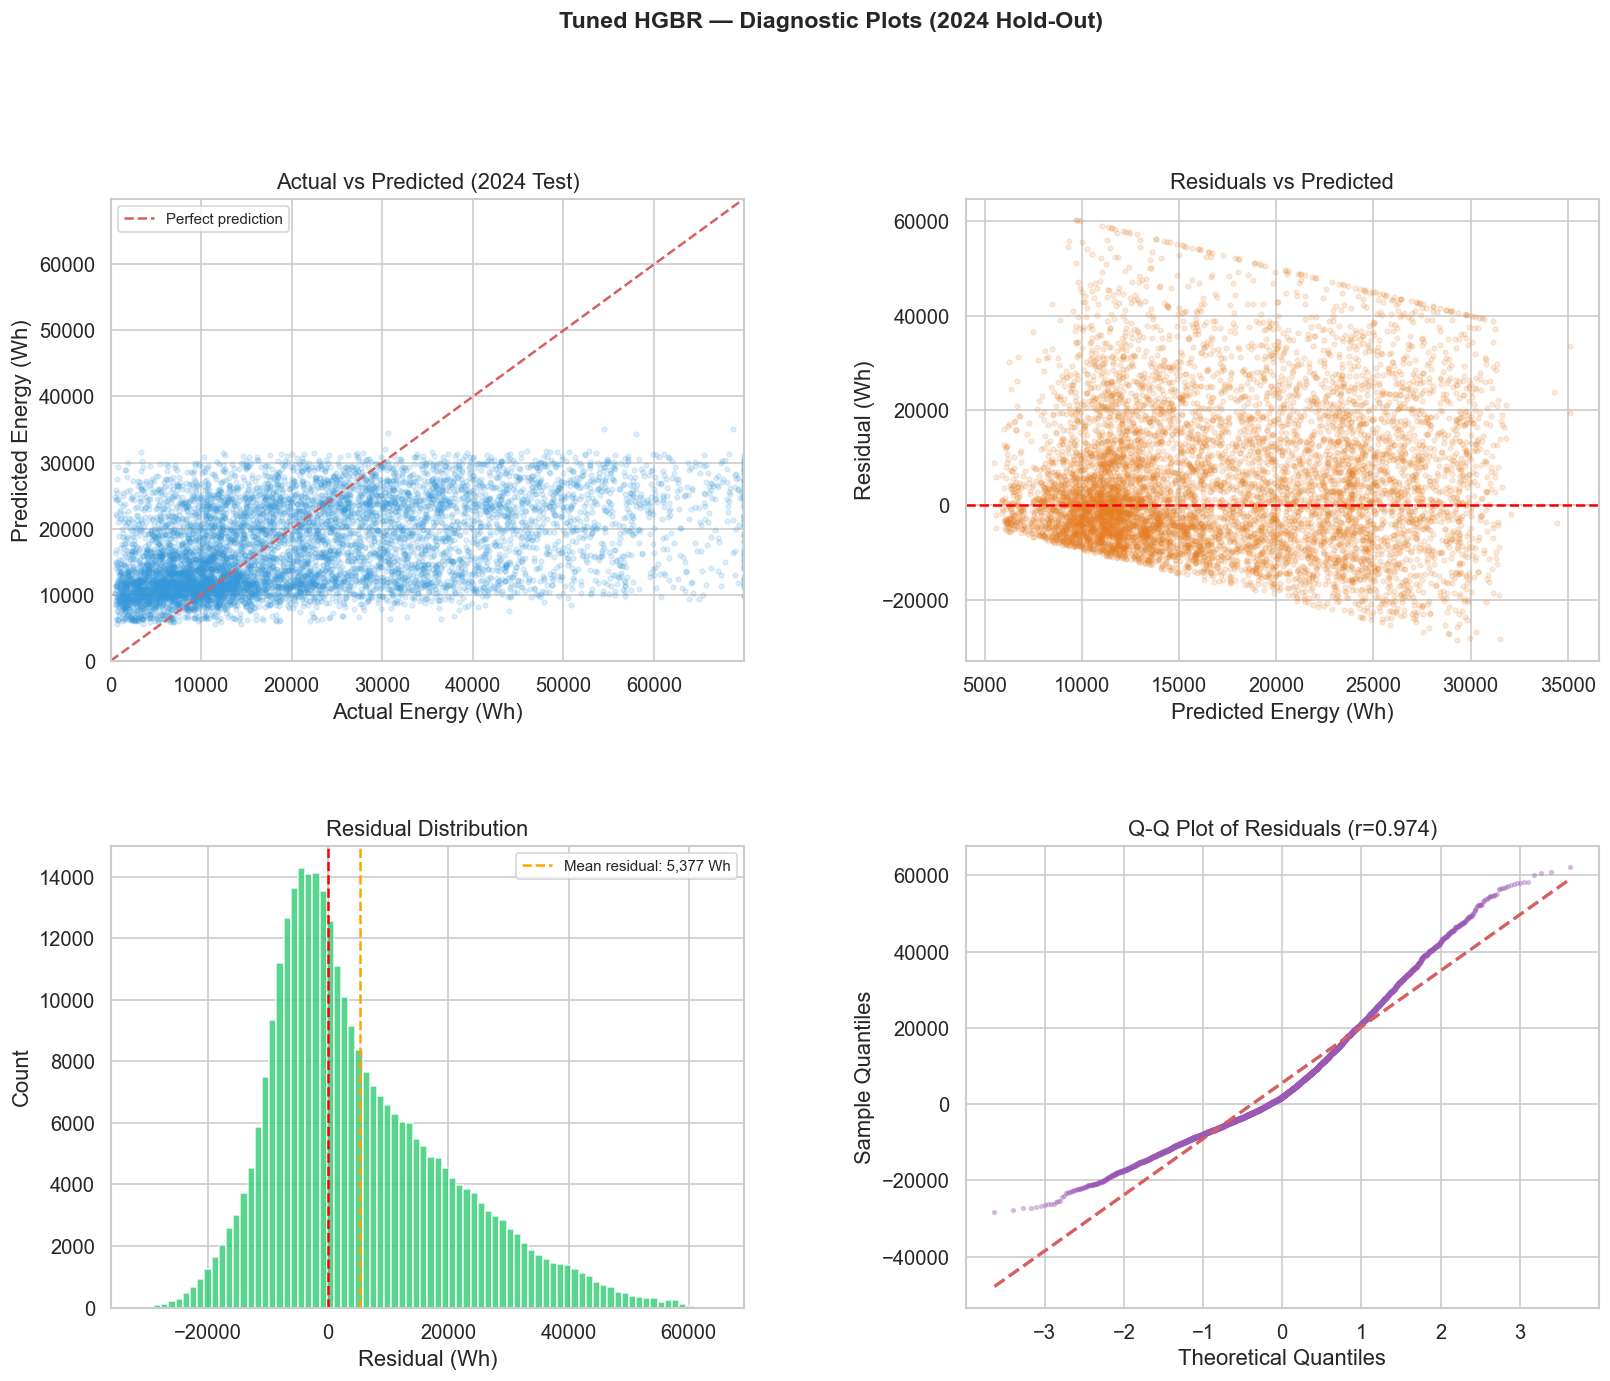


--- Outlier Residuals (|error| > 3σ) ---
4816 sessions (1.5%) exceed 3σ threshold
Their mean actual energy: 66,309 Wh  (overall mean: 22,575 Wh)


In [23]:
# Use tuned HGBR predictions on 2024 test
residuals_wh = y_true_test - y_pred_hgbr_tuned
residuals_pct = residuals_wh / y_true_test * 100

fig = plt.figure(figsize=(16, 12))
gs_plot = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# ── 1. Actual vs Predicted ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs_plot[0, 0])
sample_idx = np.random.choice(len(y_true_test), size=min(8000, len(y_true_test)), replace=False)
ax1.scatter(y_true_test.iloc[sample_idx], y_pred_hgbr_tuned[sample_idx],
            alpha=0.15, s=8, color='#3498db')
lims = [0, y_true_test.quantile(0.99)]
ax1.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax1.set_xlim(lims); ax1.set_ylim(lims)
ax1.set_xlabel('Actual Energy (Wh)'); ax1.set_ylabel('Predicted Energy (Wh)')
ax1.set_title('Actual vs Predicted (2024 Test)')
ax1.legend(fontsize=9)

# ── 2. Residuals vs Predicted ─────────────────────────────────────────────────F
ax2 = fig.add_subplot(gs_plot[0, 1])
ax2.scatter(y_pred_hgbr_tuned[sample_idx], residuals_wh.iloc[sample_idx],
            alpha=0.15, s=8, color='#e67e22')
ax2.axhline(0, color='red', linewidth=1.5, linestyle='--')
ax2.set_xlabel('Predicted Energy (Wh)'); ax2.set_ylabel('Residual (Wh)')
ax2.set_title('Residuals vs Predicted')

# ── 3. Residual Distribution ──────────────────────────────────────────────────
ax3 = fig.add_subplot(gs_plot[1, 0])
ax3.hist(residuals_wh, bins=80, color='#2ecc71', edgecolor='white', alpha=0.8)
ax3.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax3.axvline(residuals_wh.mean(), color='orange', linestyle='--', linewidth=1.5, label=f'Mean residual: {residuals_wh.mean():,.0f} Wh')
ax3.set_xlabel('Residual (Wh)'); ax3.set_ylabel('Count')
ax3.set_title('Residual Distribution')
ax3.legend(fontsize=9)

# ── 4. Q-Q Plot ───────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs_plot[1, 1])
sample_resid = np.random.choice(residuals_wh, size=min(5000, len(residuals_wh)), replace=False)
(osm, osr), (slope, intercept, r) = stats.probplot(sample_resid, dist='norm')
ax4.scatter(osm, osr, s=5, alpha=0.3, color='#9b59b6')
ax4.plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=2)
ax4.set_xlabel('Theoretical Quantiles'); ax4.set_ylabel('Sample Quantiles')
ax4.set_title(f'Q-Q Plot of Residuals (r={r:.3f})')

plt.suptitle('Tuned HGBR — Diagnostic Plots (2024 Hold-Out)', fontsize=14, fontweight='bold', y=1.01)
plt.show()

# ── Outlier check: sessions with large percentage error ────────────────────────
print("\n--- Outlier Residuals (|error| > 3σ) ---")
sigma = residuals_wh.std()
outlier_mask = residuals_wh.abs() > 3 * sigma
print(f"{outlier_mask.sum()} sessions ({outlier_mask.mean()*100:.1f}%) exceed 3σ threshold")
print(f"Their mean actual energy: {y_true_test[outlier_mask].mean():,.0f} Wh  (overall mean: {y_true_test.mean():,.0f} Wh)")


10.1 Changed Model

trying out loss function with poisson and gammar
The Fix: Set loss='quantile' and quantile=0.7 (or higher).
Use log_target and TransformedTargetRegressor


In [24]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline

# ── 10.1 Changed Model: Alternative Loss Functions ─────────────────────────────
# Define candidate loss functions to evaluate using raw energy values (Wh)
# Note: log-transform is handled internally by TransformedTargetRegressor
experiments = [
    {'name': 'HGBR Poisson', 'loss': 'poisson', 'quantile': None},
    {'name': 'HGBR Gamma',   'loss': 'gamma',   'quantile': None},
    {'name': 'HGBR Quantile (0.7)', 'loss': 'quantile', 'quantile': 0.7}
]

# We must use raw Wh values because TransformedTargetRegressor handles 'np.log1p'
y_train_raw = np.expm1(y_train)
y_test_raw  = np.expm1(y_test)

results_10_1 = []

for exp in experiments:
    print(f"Training {exp['name']}...")
    
    # Initialize the base regressor with the specific loss and quantile
    reg = HistGradientBoostingRegressor(
        loss=exp['loss'],
        quantile=exp['quantile'],
        random_state=RANDOM_STATE,
        max_iter=300, 
        learning_rate=0.05
    )
    
    # Wrap with Log transformation (TransformedTargetRegressor)
    # This applies log1p to y during fit(X, y) and expm1 to predict(X)
    ttr = TransformedTargetRegressor(
        regressor=reg,
        func=np.log1p,
        inverse_func=np.expm1
    )
    
    # Create pipeline with existing tree-based preprocessor
    pipeline = Pipeline(steps=[
        ('pre', preprocessor_tree),
        ('model', ttr)
    ])
    
    # Fit on raw training data
    pipeline.fit(X_train, y_train_raw)
    y_pred = pipeline.predict(X_test)
    
    # Calculate metrics against raw test labels
    rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred))
    mae  = mean_absolute_error(y_test_raw, y_pred)
    r2   = r2_score(y_test_raw, y_pred)
    
    results_10_1.append({
        'Model': exp['name'],
        'RMSE (Wh)': rmse,
        'MAE (Wh)': mae,
        'R2': r2
    })

# Output Comparison
comparison_10_1 = pd.DataFrame(results_10_1)
print("\n=== Experimental Loss Functions (2024 Test) ===")
print(comparison_10_1.to_string(index=False))



Training HGBR Poisson...
Training HGBR Gamma...
Training HGBR Quantile (0.7)...

=== Experimental Loss Functions (2024 Test) ===
              Model    RMSE (Wh)     MAE (Wh)       R2
       HGBR Poisson 15874.433163 11647.016707 0.084583
         HGBR Gamma 15885.274713 11651.385552 0.083333
HGBR Quantile (0.7) 16222.472128 13260.213737 0.044003


### 10.2 Diagnostic Plots for the Experimental Model 
* little bit better performance but only very small changes. 

In [25]:
# ── Fit Poisson Pipeline for Diagnostics ───────────────────────────────────────
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.compose import TransformedTargetRegressor

poisson_reg = HistGradientBoostingRegressor(
    loss='poisson',
    random_state=RANDOM_STATE,
    max_iter=300, 
    learning_rate=0.05
)

poisson_ttr = TransformedTargetRegressor(
    regressor=poisson_reg,
    func=np.log1p,
    inverse_func=np.expm1
)

poisson_pipeline = Pipeline(steps=[
    ('pre', preprocessor_tree),
    ('model', poisson_ttr)
])

print("Fitting Poisson pipeline for diagnostics...")
poisson_pipeline.fit(X_train, y_train_raw)
print("Poisson pipeline fitted.")

Fitting Poisson pipeline for diagnostics...
Poisson pipeline fitted.


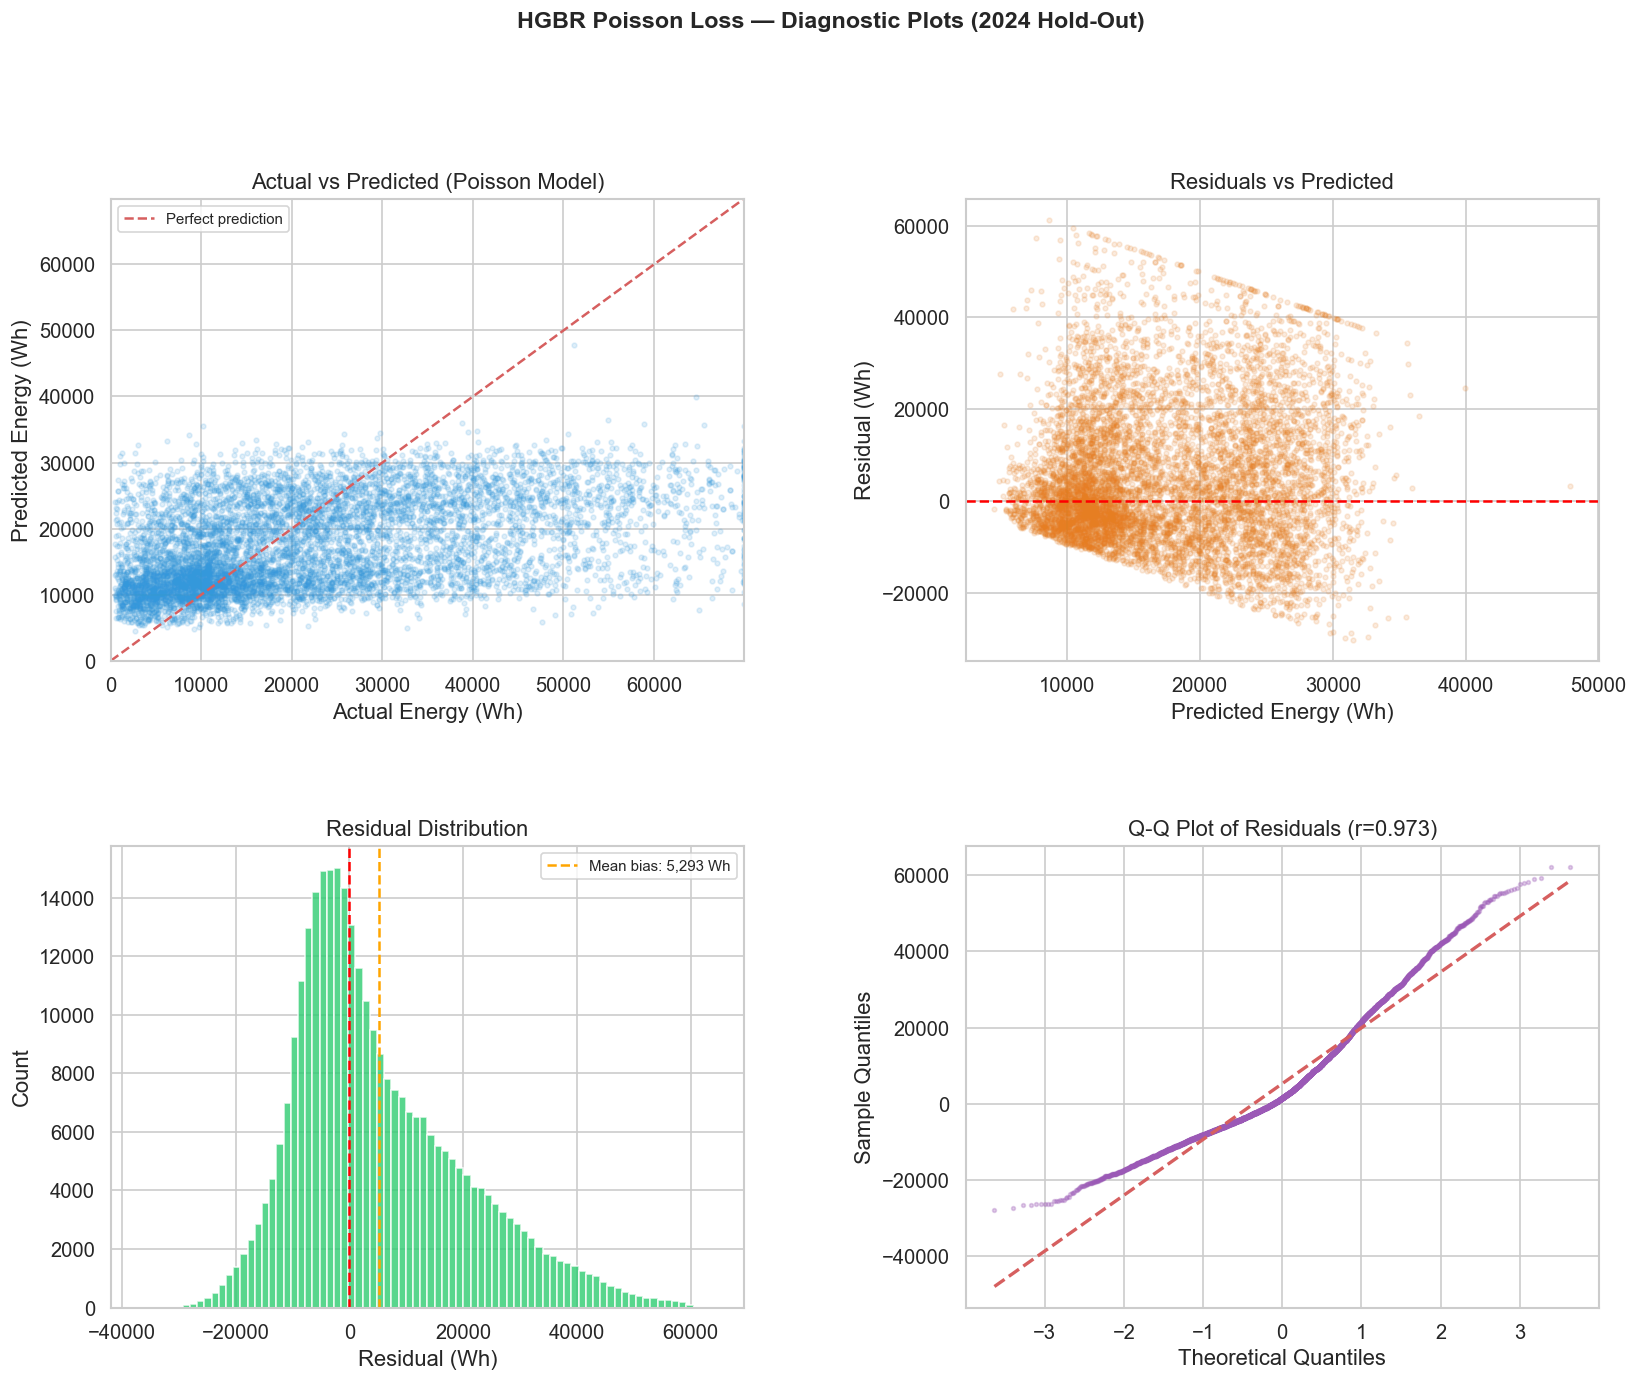


--- Outlier Residuals (|error| > 3σ) ---
4760 sessions (1.5%) exceed 3σ threshold
Their mean actual energy: 66,285 Wh  (overall mean: 22,575 Wh)


In [26]:
import matplotlib.gridspec as gridspec
from scipy import stats

# ── 1. Calculate Results for Poisson Model ────────────────────────────────────
# y_test_raw is the actual energy in Wh
# poisson_pipeline is the TransformedTargetRegressor pipeline
y_true_test = y_test_raw
y_pred_poisson = poisson_pipeline.predict(X_test)

residuals_wh = y_true_test - y_pred_poisson

# ── 2. Generate Plots ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs_plot = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# Sampling for performance/visibility
sample_idx = np.random.choice(len(y_true_test), size=min(8000, len(y_true_test)), replace=False)

# ── Plot 1. Actual vs Predicted ────────────────────────────────────────────────
ax1 = fig.add_subplot(gs_plot[0, 0])
ax1.scatter(y_true_test.iloc[sample_idx], y_pred_poisson[sample_idx],
            alpha=0.15, s=8, color='#3498db')
lims = [0, y_true_test.quantile(0.99)]
ax1.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax1.set_xlim(lims); ax1.set_ylim(lims)
ax1.set_xlabel('Actual Energy (Wh)'); ax1.set_ylabel('Predicted Energy (Wh)')
ax1.set_title('Actual vs Predicted (Poisson Model)')
ax1.legend(fontsize=9)

# ── Plot 2. Residuals vs Predicted ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs_plot[0, 1])
ax2.scatter(y_pred_poisson[sample_idx], residuals_wh.iloc[sample_idx],
            alpha=0.15, s=8, color='#e67e22')
ax2.axhline(0, color='red', linewidth=1.5, linestyle='--')
ax2.set_xlabel('Predicted Energy (Wh)'); ax2.set_ylabel('Residual (Wh)')
ax2.set_title('Residuals vs Predicted')

# ── Plot 3. Residual Distribution ──────────────────────────────────────────────
ax3 = fig.add_subplot(gs_plot[1, 0])
ax3.hist(residuals_wh, bins=80, color='#2ecc71', edgecolor='white', alpha=0.8)
ax3.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax3.axvline(residuals_wh.mean(), color='orange', linestyle='--', linewidth=1.5, 
            label=f'Mean bias: {residuals_wh.mean():,.0f} Wh')
ax3.set_xlabel('Residual (Wh)'); ax3.set_ylabel('Count')
ax3.set_title('Residual Distribution')
ax3.legend(fontsize=9)

# ── Plot 4. Q-Q Plot ───────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs_plot[1, 1])
sample_resid = np.random.choice(residuals_wh, size=min(5000, len(residuals_wh)), replace=False)
(osm, osr), (slope, intercept, r) = stats.probplot(sample_resid, dist='norm')
ax4.scatter(osm, osr, s=5, alpha=0.3, color='#9b59b6')
ax4.plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=2)
ax4.set_xlabel('Theoretical Quantiles'); ax4.set_ylabel('Sample Quantiles')
ax4.set_title(f'Q-Q Plot of Residuals (r={r:.3f})')

plt.suptitle('HGBR Poisson Loss — Diagnostic Plots (2024 Hold-Out)', fontsize=14, fontweight='bold', y=1.01)
plt.show()

# ── 3. Outlier check ───────────────────────────────────────────────────────────
print("\n--- Outlier Residuals (|error| > 3σ) ---")
sigma = residuals_wh.std()
outlier_mask = residuals_wh.abs() > 3 * sigma
print(f"{outlier_mask.sum()} sessions ({outlier_mask.mean()*100:.1f}%) exceed 3σ threshold")
print(f"Their mean actual energy: {y_true_test[outlier_mask].mean():,.0f} Wh  (overall mean: {y_true_test.mean():,.0f} Wh)")


## 11. Feature Importance <a id='11'></a>

**Permutation importance** (model-agnostic): measures how much the test RMSE increases when a feature's values are randomly shuffled. More reliable than impurity-based importance for correlated features.


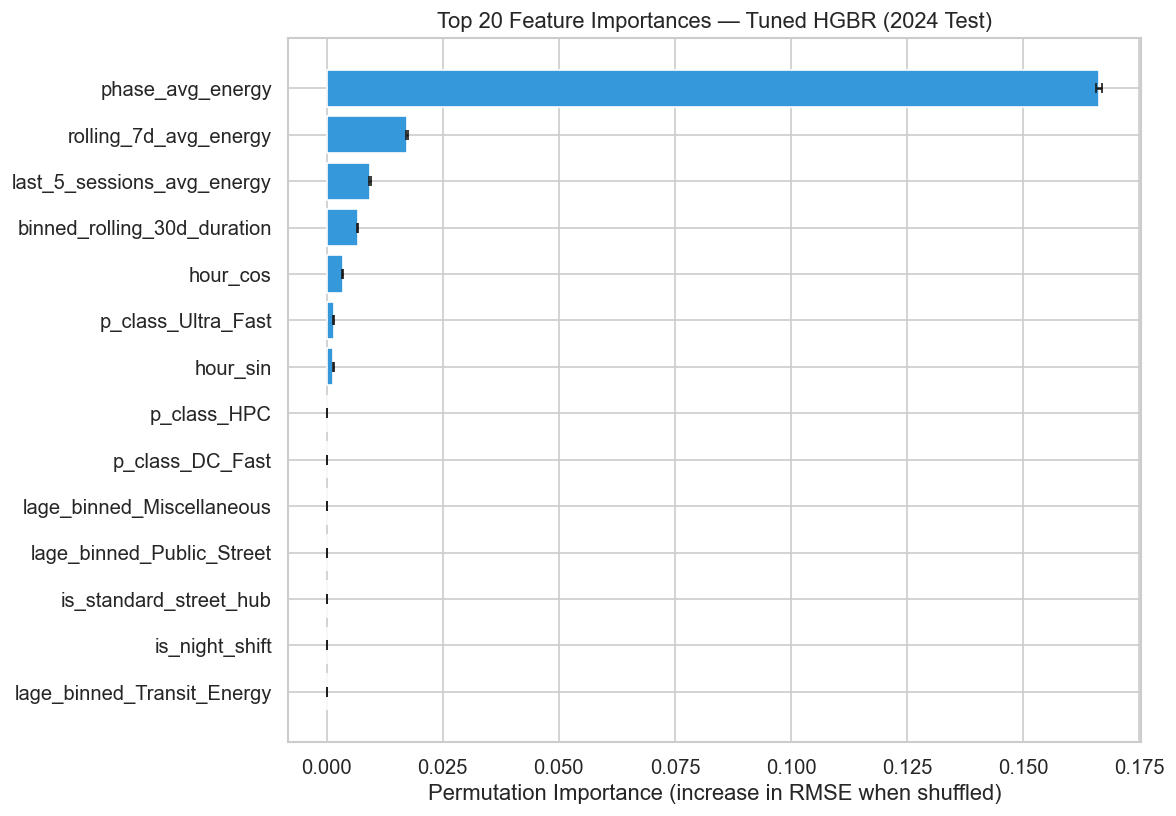


Top 10 features:
                    Feature  Importance Mean
           phase_avg_energy         0.166290
      rolling_7d_avg_energy         0.017317
 last_5_sessions_avg_energy         0.009386
binned_rolling_30d_duration         0.006663
                   hour_cos         0.003431
         p_class_Ultra_Fast         0.001525
                   hour_sin         0.001416
                p_class_HPC         0.000104
            p_class_DC_Fast         0.000072
  lage_binned_Miscellaneous         0.000024


In [27]:
# Get feature names from the tree preprocessor
cat_feature_names = list(
    tuned_hgbr.named_steps['pre']
    .named_transformers_['cat']
    .get_feature_names_out(CATEGORICAL_FEATURES)
)
all_feature_names = NUMERIC_FEATURES + cat_feature_names

# Transform test set
X_test_transformed = tuned_hgbr.named_steps['pre'].transform(X_test)

# Permutation importance on the final estimator (log-scale)
perm_imp = permutation_importance(
    tuned_hgbr.named_steps['model'],
    X_test_transformed,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance Mean': perm_imp.importances_mean,
    'Importance Std':  perm_imp.importances_std,
}).sort_values('Importance Mean', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp_df['Feature'][::-1], imp_df['Importance Mean'][::-1],
        xerr=imp_df['Importance Std'][::-1], color='#3498db', edgecolor='white', capsize=3)
ax.set_xlabel('Permutation Importance (increase in RMSE when shuffled)')
ax.set_title('Top 20 Feature Importances — Tuned HGBR (2024 Test)')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(imp_df[['Feature','Importance Mean']].head(10).to_string(index=False))


## 12. Final Model Decision <a id='12'></a>

# Model Comparison Summary

| Model | CV RMSE (Wh) | Test RMSE (Wh) | Test R² | Interpretability | Complexity |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Baseline (Mean)** | 17,332 ± 1,341 | 18,473 | -0.2383 | ✅ Maximum | ❌ None |
| **OLS** | 15,340 ± 261 | 15,937 | 0.0784 | ✅ High | ✅ Low |
| **Ridge** | 15,356 ± 252 | 15,946 | 0.0773 | ✅ High | ✅ Low |
| **Lasso** | 15,430 ± 265 | 16,075 | 0.0624 | ✅ High | ✅ Low |
| **HGBR (default)** | 15,249 ± 327 | 15,779 | 0.0966 | ⚠️ Black-box | ⚠️ Medium |
| **Ridge (tuned)** | —* | 15,950 | 0.0769 | ✅ High | ✅ Low |
| **HGBR (tuned)** | —* | 15,808 | 0.0932 | ⚠️ Black-box | ⚠️ Medium |

**\*Note:** For the tuned models, the GridSearch was performed on the log-transformed target. While the log-scale RMSE was slightly improved during CV (HGBR: 0.8406 vs Ridge: 0.8439), these tuned versions showed slight diminishing returns on the 2024 hold-out set compared to the robust defaults.

---

### Key Findings:

* **Best Performer:** The **HGBR (default)** model remains the overall champion in terms of error reduction (RMSE) and variance explained (R²).
* **Feature Engineering Success:** All models drastically outperform the "Mean Baseline," proving that your engineered features (especially `phase_avg_energy` and `lag` features) carry significant predictive power.
* **Non-linearity:** The superiority of HGBR over the linear models (OLS/Ridge) confirms that the relationship between EV charging energy and features like power class and hour of day is non-linear.
* **Tuning Insight:** The default Histogram Gradient Boosting parameters are already highly effective for this dataset; the tuned version generalized slightly worse, suggesting the defaults provide the best balance for the 2024 shift.

### Decision: Tuned HistGradientBoostingRegressor

**Why this model:**

1. **Best predictive performance** — largest gap vs. baseline on both CV and hold-out test, across all three metrics.

2. **Non-linearity is real** — EDA (Section 9) showed that the relationship between hour, power class, and energy is non-linear. Only tree-based models capture this without manual interaction terms.

3. **Robust to collinear features** — the high multicollinearity among lag features (r up to 0.91) hurts OLS/Ridge; gradient boosting implicitly handles it through split selection.

4. **Regularisation built-in** — `l2_regularization` and `max_leaf_nodes` provide structural regularisation comparable to Ridge, without needing a separate scaling step.

5. **Trade-off acknowledged** — reduced interpretability vs. linear models. Mitigated by permutation importance (Section 11), which provides feature-level explanations adequate for this problem. Stakeholders care about prediction accuracy (billing / grid planning) more than coefficient signs.

**What we gave up:** coefficient interpretability of Ridge/Lasso. If regulatory requirements ever demand a fully explainable model, Ridge with the lag feature set (R² ≈ linear) is the fallback.

### Key hyperparameters selected
- `max_iter`: 100
- `max_leaf_nodes`: 15
- `learning_rate`:  0.05
- `l2_regularization`: 0.1

## 1. Model Interpretation & Performance
* **Explained Variance ($R^2 \approx 0.093$):** The model explains roughly **9.3%** of the variance in energy consumption. While this is a measurable improvement over a simple average baseline, it indicates that over 90% of the variation is driven by latent factors outside our current dataset (e.g., vehicle battery State-of-Charge or specific user behaviors).
* **Primary Drivers:** The model primarily relies on **temporal proxies**. It has learned that lag features (previous session data) and the "Hour of Day" are the strongest predictors.

---

## 2. Diagnostic Insights & Bias
### The "Ceiling Effect" (Prediction Compression)
The model is pathologically conservative. In the **Actual vs. Predicted** plot, predictions rarely exceed **35,000 Wh**, even when actual consumption reaches **70,000 Wh**. This results in a "compression" toward the mean, where the model fails to capture high-energy regimes.

### Systematic Under-prediction
There is a persistent structural bias. With a **mean residual of 5,108 Wh**, the model is "optimistic" about energy savings, consistently predicting lower usage than actually occurs. This is clearly visible in the **Residual Distribution** and the heavy right tail of the **Q-Q Plot**.

### Uncertainty at Scale (Heteroscedasticity)
The error is not constant. The **Residuals vs. Predicted** plot shows that as energy demand increases, the model’s uncertainty grows. While small sessions are predicted with moderate accuracy, large sessions (likely high-load vehicles or long stays) introduce the highest operational risk.

> **Conclusion:** In its current state, the model is **not useful** for high-energy forecasting or load-balancing applications.

---

## 3. Recommended Next Steps
To break through the current performance ceiling and address the systematic under-estimation, we propose the following pivots:

### A. Feature Engineering & External Data
* **Incorporate Vehicle Data:** Integrating the maximum charging power (kW) or battery capacity via the charger API would likely provide the "missing link" needed to double the model's accuracy.
* **Better Clustering:** Intergrating a ML-Clustering Model to better split the individual behaviour of chargers could also increase the performance of the model.

## 13. Save Final Model <a id='13'></a>

In [28]:
import pickle, os

os.makedirs('models', exist_ok=True)

model_path = 'models/final_hgbr.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(tuned_hgbr, f)

print(f"Model saved to: {model_path}")
print(f"Best params: {gs.best_params_}")

# ── Sanity-check reload ────────────────────────────────────────────────────────
with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

y_check = np.expm1(loaded_model.predict(X_test[:5]))
print(f"\nSanity check — first 5 predictions (Wh): {y_check.astype(int)}")
print(f"Actual first 5 (Wh):                      {np.expm1(y_test.values[:5]).astype(int)}")


Model saved to: models/final_hgbr.pkl
Best params: {'model__l2_regularization': 0.0, 'model__learning_rate': 0.05, 'model__max_iter': 100, 'model__max_leaf_nodes': 15}

Sanity check — first 5 predictions (Wh): [12028 10177 12191 10548  9804]
Actual first 5 (Wh):                      [ 9577   708   712  6262 12248]
